# Proyecto final: embeddings con Don Quijote

Este notebook usa solo el caso de *Don Quijote de la Mancha* y compara dos enfoques de optimización restringida: penalización cuadrática y barrera logarítmica.

Vocabulario: ['quijote', 'sancho', 'rocinante', 'dulcinea', 'molinos', 'viento', 'caballero', 'aventuras', 'mancha', 'gigantes', 'batalla', 'escudero', 'novela', 'juicio']

Resultados finales
------------------------------------------------------------------------
metodo            data_loss     orth_error    max_norm_sq      min_slack
penalizacion         1.3454         0.0138         0.2887         0.7113
barrera              1.3473         0.0124         0.2288         0.7712

Vecinos cercanos con barrera
     quijote -> dulcinea, molinos, rocinante
      sancho -> escudero, viento, molinos
   rocinante -> dulcinea, quijote, molinos
    dulcinea -> quijote, rocinante, molinos
     molinos -> quijote, dulcinea, viento
      viento -> escudero, molinos, sancho
   caballero -> mancha, aventuras, rocinante
   aventuras -> mancha, juicio, caballero
      mancha -> caballero, aventuras, juicio
    gigantes -> batalla, sancho, escudero
     batalla -> gigantes, novela, sancho
    escudero 

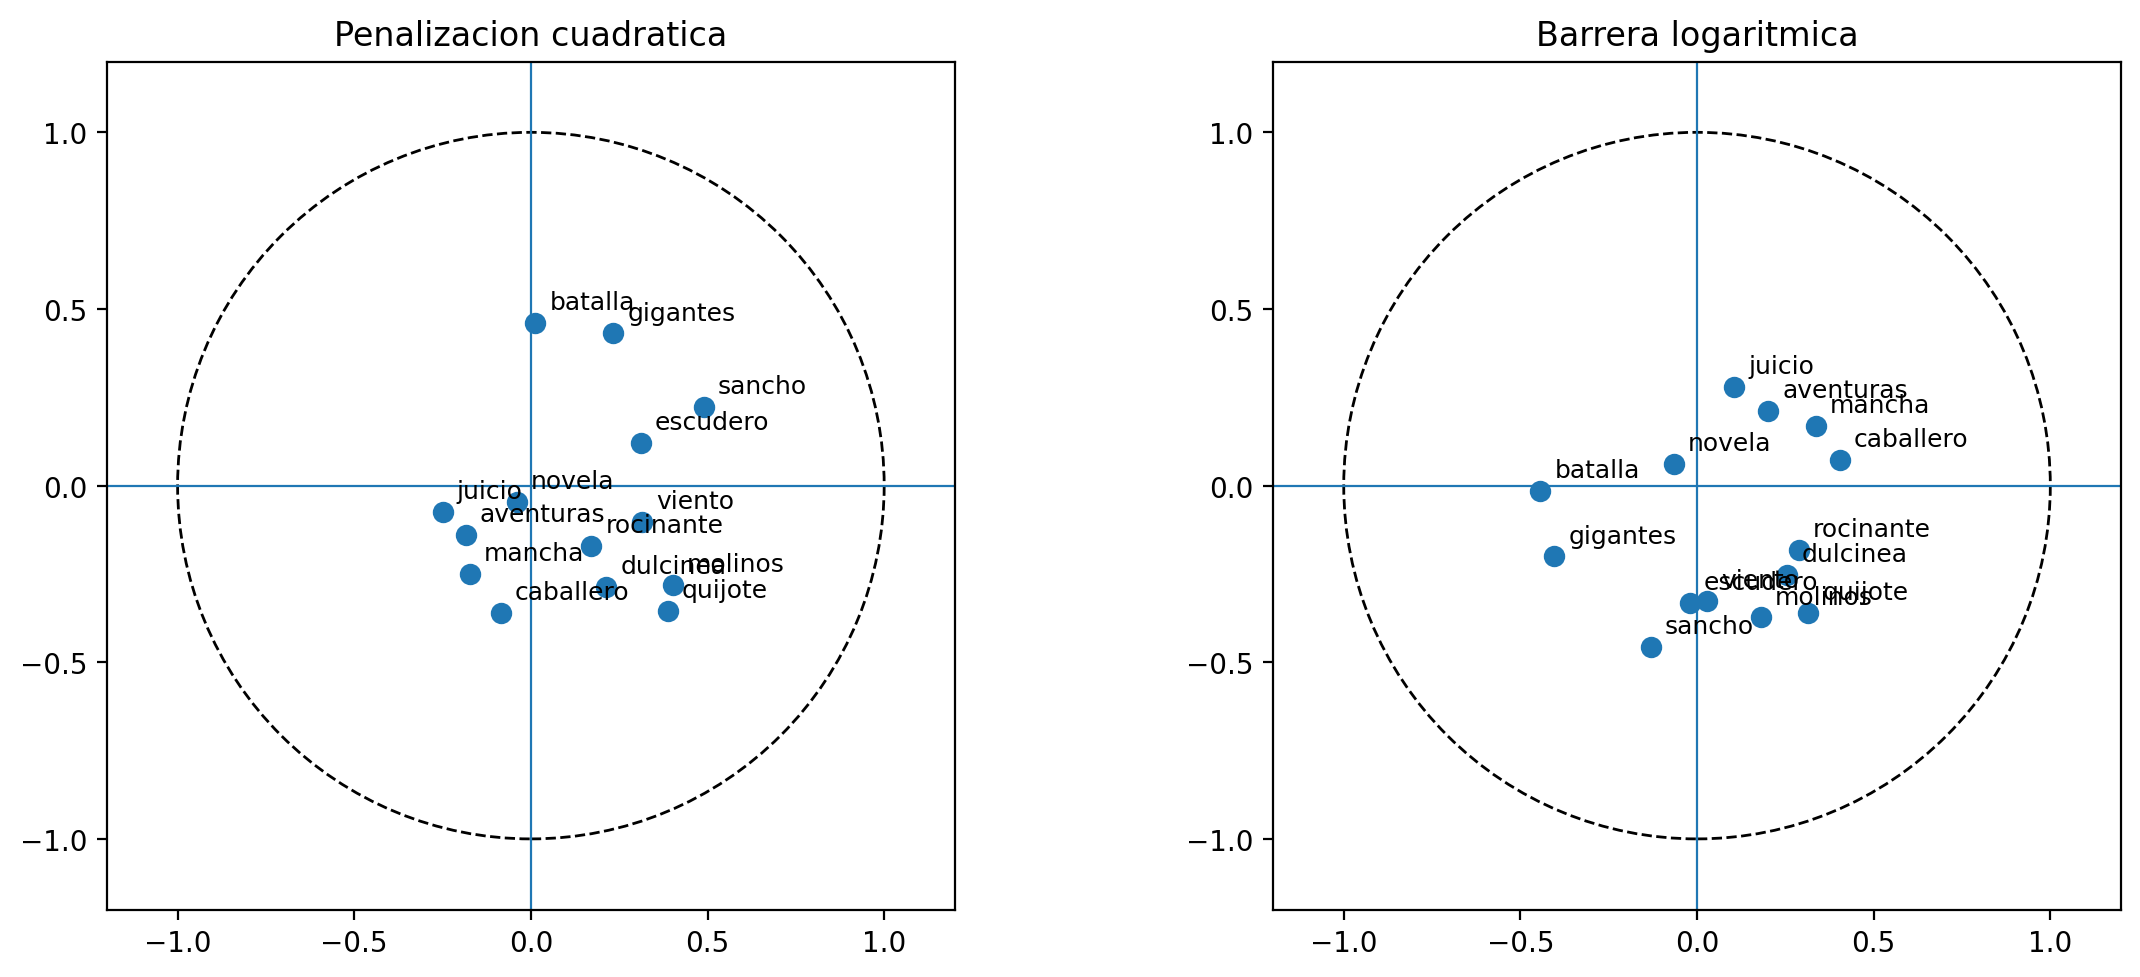

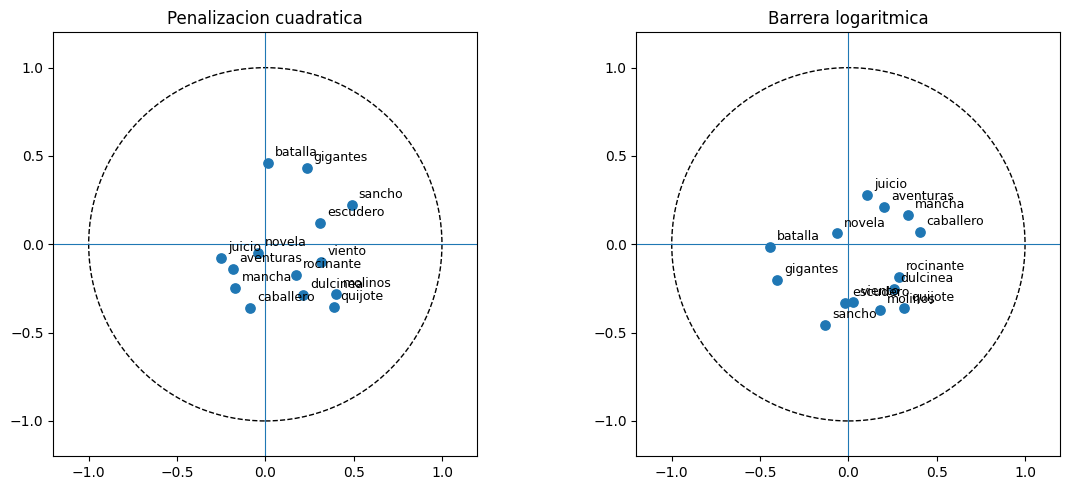

In [1]:
from IPython.display import Image, display

from quijote_minimo import (
    build_quijote_dataset,
    data_loss,
    nearest_neighbors,
    plot_embeddings,
    summarize_constraints,
    train_barrier,
    train_penalty,
)

dataset = build_quijote_dataset()
E_penalty = train_penalty(dataset)
E_barrier = train_barrier(dataset)

penalty_summary = summarize_constraints(E_penalty, c=1.0)
barrier_summary = summarize_constraints(E_barrier, c=1.0)

print("Vocabulario:", dataset["vocab"])
print()
print("Resultados finales")
print("-" * 72)
print(f"{'metodo':<15}{'data_loss':>12}{'orth_error':>15}{'max_norm_sq':>15}{'min_slack':>15}")
print(
    f"{'penalizacion':<15}"
    f"{data_loss(E_penalty, dataset['positive_pairs'], dataset['positive_weights']):>12.4f}"
    f"{penalty_summary['orth_error']:>15.4f}"
    f"{penalty_summary['max_norm_sq']:>15.4f}"
    f"{penalty_summary['min_slack']:>15.4f}"
)
print(
    f"{'barrera':<15}"
    f"{data_loss(E_barrier, dataset['positive_pairs'], dataset['positive_weights']):>12.4f}"
    f"{barrier_summary['orth_error']:>15.4f}"
    f"{barrier_summary['max_norm_sq']:>15.4f}"
    f"{barrier_summary['min_slack']:>15.4f}"
)

print()
print("Vecinos cercanos con barrera")
for token, neighbors in nearest_neighbors(E_barrier, dataset).items():
    print(f"{token:>12} -> {', '.join(neighbors)}")

plot_embeddings(E_penalty, E_barrier, dataset)
display(Image(filename="embeddings_quijote.png"))

## Lectura rápida

- Ambos métodos ajustan casi igual los datos.
- La barrera deja más holgura respecto a la restricción de norma.
- Las relaciones `quijote`, `rocinante`, `dulcinea`, `sancho` y `escudero` sí aparecen de forma razonable.